# Task 4B: SEAL-Augmented LoRA — Steel Surface Defects

Image + Prompt → CoT Description + JSON

GPT-4.1 generates answer-conditioned reasoning for each training image.
Same 18 images as Direct, but 4 examples per image = 72 training pairs.
15 epochs, lr=1e-5.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import json, re, time, torch, gc, random, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

random.seed(SEED)
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Step 1: Select Training Images (same seed = same selection as Direct)

In [2]:
train_data = []
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_IMAGES_DIR, cls)
    all_imgs = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.png', '.bmp'))])
    selected = random.sample(all_imgs, IMAGES_PER_CLASS)
    for img_name in selected:
        train_data.append({'image': os.path.join(cls_dir, img_name), 'class': cls})
    print(f'{cls}: {selected}')
print(f'\nTotal: {len(train_data)} training images')

crazing: ['crazing_3.jpg', 'crazing_124.jpg', 'crazing_104.jpg', 'crazing_53.jpg', 'crazing_162.jpg']
inclusion: ['inclusion_155.jpg', 'inclusion_150.jpg', 'inclusion_130.jpg', 'inclusion_52.jpg', 'inclusion_122.jpg']
patches: ['patches_39.jpg', 'patches_53.jpg', 'patches_89.jpg', 'patches_224.jpg', 'patches_119.jpg']
pitted_surface: ['pitted_surface_235.jpg', 'pitted_surface_197.jpg', 'pitted_surface_106.jpg', 'pitted_surface_105.jpg', 'pitted_surface_12.jpg']
rolled-in_scale: ['rolled-in_scale_149.jpg', 'rolled-in_scale_152.jpg', 'rolled-in_scale_215.jpg', 'rolled-in_scale_238.jpg', 'rolled-in_scale_104.jpg']
scratches: ['scratches_228.jpg', 'scratches_144.jpg', 'scratches_48.jpg', 'scratches_32.jpg', 'scratches_44.jpg']

Total: 30 training images


## Step 2: Generate CoT Descriptions via GPT-4.1

In [3]:
from openai import AzureOpenAI

API_KEY = '871a30b46ebf4297a8938ff5fca23646'
client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=API_KEY, api_version=AZURE_API_VERSION)
print(f'GPT-4.1 client ready (key set: {bool(API_KEY)})')

GPT-4.1 client ready (key set: True)


In [4]:
def encode_image(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def generate_cot(image_path, defect_class):
    img_b64 = encode_image(image_path)
    resp = client.chat.completions.create(
        model=AZURE_DEPLOYMENT, temperature=0.7, max_completion_tokens=512,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{img_b64}'}},
            {'type': 'text', 'text': make_seal_prompt(defect_class)},
        ]}])
    return resp.choices[0].message.content.strip()

print('CoT generation ready.')

CoT generation ready.


In [5]:
COT_PER_IMAGE = 3
augmented_path = 'training_data_augmented.jsonl'
PROMPT = make_prompt()
# Remove the last 2 lines (empty line + 'Respond with ONLY JSON...' + JSON template) for description examples
PROMPT_NO_JSON = '\n'.join(PROMPT.split('\n')[:-2])

if os.path.exists(augmented_path):
    with open(augmented_path) as f:
        augmented_data = [json.loads(l) for l in f]
    print(f'Loaded existing: {len(augmented_data)} examples')
else:
    augmented_data = []
    for idx, entry in enumerate(train_data):
        cls = entry['class']
        img = entry['image']
        gt_json = json.dumps({'defect_class': cls})
        print(f'[{idx+1}/{len(train_data)}] {cls}: {os.path.basename(img)}')
        
        # 1 direct example (full prompt with JSON instruction)
        augmented_data.append({'messages': [
            {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]},
            {'role': 'assistant', 'content': gt_json},
        ]})
        
        # 3 CoT examples (prompt WITHOUT JSON line, response = description + JSON appended by us)
        for j in range(COT_PER_IMAGE):
            try:
                description = generate_cot(img, cls)
                # GPT-4.1 returns ONLY the description — we append the JSON ourselves
                cot_response = description.strip() + '\n' + gt_json
                augmented_data.append({'messages': [
                    {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT_NO_JSON}]},
                    {'role': 'assistant', 'content': cot_response},
                ]})
                print(f'  CoT {j+1}: {len(description)} chars')
            except Exception as e:
                print(f'  CoT {j+1}: ERROR — {e}')
            time.sleep(0.3)
    
    with open(augmented_path, 'w') as f:
        for ex in augmented_data: f.write(json.dumps(ex) + '\n')
    print(f'\nSaved {len(augmented_data)} examples ({len(train_data)} direct + {len(augmented_data)-len(train_data)} CoT)')

[1/30] crazing: crazing_3.jpg
  CoT 1: 469 chars
  CoT 2: 528 chars
  CoT 3: 420 chars
[2/30] crazing: crazing_124.jpg
  CoT 1: 464 chars
  CoT 2: 538 chars
  CoT 3: 495 chars
[3/30] crazing: crazing_104.jpg
  CoT 1: 470 chars
  CoT 2: 554 chars
  CoT 3: 537 chars
[4/30] crazing: crazing_53.jpg
  CoT 1: 497 chars
  CoT 2: 536 chars
  CoT 3: 546 chars
[5/30] crazing: crazing_162.jpg
  CoT 1: 487 chars
  CoT 2: 512 chars
  CoT 3: 488 chars
[6/30] inclusion: inclusion_155.jpg
  CoT 1: 493 chars
  CoT 2: 571 chars
  CoT 3: 532 chars
[7/30] inclusion: inclusion_150.jpg
  CoT 1: 488 chars
  CoT 2: 469 chars
  CoT 3: 464 chars
[8/30] inclusion: inclusion_130.jpg
  CoT 1: 511 chars
  CoT 2: 515 chars
  CoT 3: 469 chars
[9/30] inclusion: inclusion_52.jpg
  CoT 1: 519 chars
  CoT 2: 587 chars
  CoT 3: 497 chars
[10/30] inclusion: inclusion_122.jpg
  CoT 1: 516 chars
  CoT 2: 423 chars
  CoT 3: 439 chars
[11/30] patches: patches_39.jpg
  CoT 1: 559 chars
  CoT 2: 506 chars
  CoT 3: 513 chars
[12/

In [6]:
# Preview a CoT example
cot_ex = [ex for ex in augmented_data if len(ex['messages'][1]['content']) > 100]
if cot_ex:
    print('=== Sample CoT ===')
    print(cot_ex[0]['messages'][1]['content'][:500])

=== Sample CoT ===
The image shows a surface covered with a fine, web-like network of shallow cracks that are thin, irregular, and multi-directional, creating a fragmented yet relatively uniform texture and brightness. These visual cues match the definition of crazing, as the cracks form a mosaic pattern across the steel strip. It is not scratches, because there are no few sharp lines in a single direction; instead, the cracks form an interconnected network characteristic of crazing.
{"defect_class": "crazing"}


## Step 3: Load Model + LoRA

In [7]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', dtype=torch.bfloat16,
    max_memory={0: '6GiB', 1: '15GiB'})
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')

print(f'Fresh model loaded (BF16).')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.21it/s]


Fresh model loaded (BF16).
  GPU 0: 3.7 GB
  GPU 1: 3.9 GB


## Step 4: Dataset + Training

In [8]:
class SteelDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        img_path = next((c['image'] for c in msgs[0]['content'] if c['type']=='image'), None)
        user_text = next((c['text'] for c in msgs[0]['content'] if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str): assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}

EPOCHS = 40
LR = 2e-5
GRAD_ACCUM = 4

def train_lora(base_model, data_path, output_dir, epochs=EPOCHS, lr=LR):
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = SteelDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, lr={lr}')
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    model.train()
    losses = []
    t_start = time.time()
    for epoch in range(epochs):
        epoch_loss = 0; n_ok = 0
        for i in range(len(dataset)):
            try:
                batch = dataset[i]
                ids = batch['input_ids'].unsqueeze(0).to(model.device)
                mask = batch['attention_mask'].unsqueeze(0).to(model.device)
                lab = batch['labels'].unsqueeze(0).to(model.device)
                kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
                if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
                if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
                out = model(**kw)
                loss = out.loss / GRAD_ACCUM
                loss.backward()
                epoch_loss += loss.item() * GRAD_ACCUM; n_ok += 1
                if (i+1) % GRAD_ACCUM == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step(); scheduler.step(); optimizer.zero_grad()
                del ids, mask, lab, out, loss; torch.cuda.empty_cache()
            except Exception as e:
                print(f'  Skip {i} (epoch {epoch+1}): {e}')
                optimizer.zero_grad(); torch.cuda.empty_cache()
        avg = epoch_loss / max(n_ok, 1)
        losses.append(avg)
        if (epoch+1) % 3 == 0 or epoch == 0:
            elapsed = time.time() - t_start
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e} — {elapsed:.0f}s')
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    plt.figure(figsize=(8,4))
    plt.plot(range(1,len(losses)+1), losses)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Training Loss ({output_dir})')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return model, losses

print('Training function ready.')

Training function ready.


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 120 examples, 40 epochs, lr=2e-05


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization i

  Epoch 1/40 — loss: 1.5525 — lr: 5.00e-06 — 264s
  Epoch 3/40 — loss: 1.1194 — lr: 1.50e-05 — 790s
  Epoch 6/40 — loss: 0.6530 — lr: 1.98e-05 — 1574s
  Epoch 9/40 — loss: 0.4507 — lr: 1.91e-05 — 2361s
  Epoch 12/40 — loss: 0.2992 — lr: 1.77e-05 — 3149s
  Epoch 15/40 — loss: 0.2144 — lr: 1.57e-05 — 3935s
  Epoch 18/40 — loss: 0.1593 — lr: 1.34e-05 — 4725s
  Epoch 21/40 — loss: 0.1143 — lr: 1.09e-05 — 5516s
  Epoch 24/40 — loss: 0.0756 — lr: 8.26e-06 — 6300s
  Epoch 27/40 — loss: 0.0584 — lr: 5.77e-06 — 7083s
  Epoch 30/40 — loss: 0.0366 — lr: 3.57e-06 — 7867s
  Epoch 33/40 — loss: 0.0277 — lr: 1.81e-06 — 8651s
  Epoch 36/40 — loss: 0.0227 — lr: 6.03e-07 — 9434s
  Epoch 39/40 — loss: 0.0216 — lr: 3.81e-08 — 10218s
Adapter saved to lora_augmented/


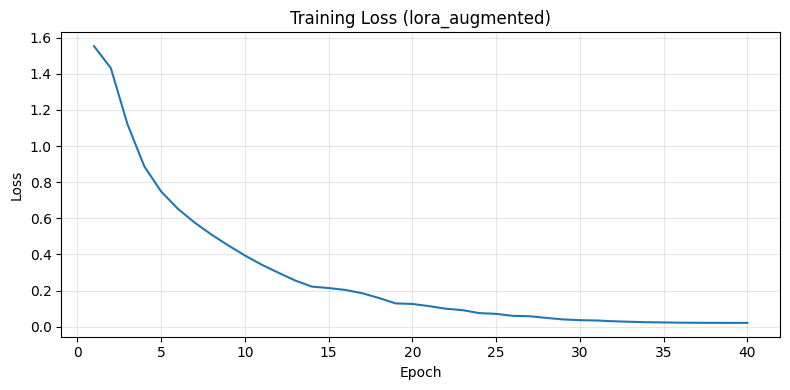

In [9]:
model, losses = train_lora(base_model, augmented_path, 'lora_augmented', epochs=EPOCHS, lr=LR)

## Step 5: Evaluate on 360 Test Images

In [10]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w-]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):
        if cls in raw_lower: return {'defect_class': cls}
    return None

def evaluate(model, processor, test_dir, classes, prompt):
    model.eval()
    results = []; correct = 0; valid = 0; total_time = 0
    manifest = []
    for cls in classes:
        cls_dir = os.path.join(test_dir, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.png', '.bmp')):
                manifest.append({'image': os.path.join(cls_dir, f), 'class': cls})
    print(f'Evaluating on {len(manifest)} images...')
    for i, entry in enumerate(manifest):
        image = Image.open(entry['image']).convert('RGB')
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t = time.time()
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=256, temperature=0.1, do_sample=True)
        elapsed = time.time() - t; total_time += elapsed
        out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        parsed = parse_response(out)
        gt = entry['class']; ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'predicted': parsed,
            'raw': out, 'correct': ok, 'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        if (i+1) % 60 == 0:
            n = i+1; print(f'  [{n}/{len(manifest)}] Acc: {correct}/{n} ({correct/n*100:.0f}%)')
    return results, correct, valid, total_time

print('Eval functions ready.')

Eval functions ready.


In [11]:
PROMPT = make_prompt()
results, correct, valid, eval_time = evaluate(model, processor, TEST_IMAGES_DIR, CLASSES, PROMPT)
n = len(results)
print(f'\nSEAL LoRA: {correct}/{n} ({correct/n*100:.1f}%) | JSON: {valid}/{n} | {eval_time/n:.1f}s/img')

# Per-class
print(f'\nPer-class:')
by_class = defaultdict(list)
for r in results: by_class[r['class']].append(r)
for cls in CLASSES:
    cr = by_class[cls]; c = sum(1 for r in cr if r['correct'])
    print(f'  {cls:<22} {c:>3}/{len(cr)} ({c/len(cr)*100:.0f}%)')

Evaluating on 360 images...
  [60/360] Acc: 41/60 (68%)
  [120/360] Acc: 60/120 (50%)
  [180/360] Acc: 105/180 (58%)
  [240/360] Acc: 156/240 (65%)
  [300/360] Acc: 189/300 (63%)
  [360/360] Acc: 240/360 (67%)

SEAL LoRA: 240/360 (66.7%) | JSON: 360/360 | 2.3s/img

Per-class:
  crazing                 41/60 (68%)
  inclusion               19/60 (32%)
  patches                 45/60 (75%)
  pitted_surface          51/60 (85%)
  rolled-in_scale         33/60 (55%)
  scratches               51/60 (85%)


In [12]:
with open('results_augmented.json', 'w') as f:
    json.dump({'model': MODEL_ID, 'method': 'seal_augmented_lora', 'dataset': 'NEU-CLS',
        'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
        'json_validity_pct': round(valid/n*100, 1), 'avg_inference_time_s': round(eval_time/n, 2),
        'training_images': 18, 'training_examples': len(augmented_data),
        'epochs': EPOCHS, 'lr': LR, 'results': results}, f, indent=2)
print('Saved results_augmented.json')

Saved results_augmented.json


## Comparison

In [13]:
print(f'{"Method":<30} {"Accuracy":>10}')
print('=' * 42)
print(f'{"Qwen base (ZS)":<30} {"21.7%":>10}')
print(f'{"Qwen base (FS)":<30} {"22.8%":>10}')
if os.path.exists('results_direct.json'):
    with open('results_direct.json') as f: d = json.load(f)
    print(f'{"Direct LoRA (18 imgs)":<30} {d["accuracy_pct"]:>9.1f}%')
print(f'{"SEAL LoRA (18 imgs, 72 ex)":<30} {correct/n*100:>9.1f}%')
print(f'{"GPT-4.1 FS (teacher)":<30} {"91.1%":>10}')
print(f'{"Random chance":<30} {"16.7%":>10}')

Method                           Accuracy
Qwen base (ZS)                      21.7%
Qwen base (FS)                      22.8%
Direct LoRA (18 imgs)               54.4%
SEAL LoRA (18 imgs, 72 ex)          66.7%
GPT-4.1 FS (teacher)                91.1%
Random chance                       16.7%
